##### Classical SVM Implementation - Spambase - PCA

In [1]:
# =============================================================================
# SECTION 1: IMPORTS
# =============================================================================
# --- Import Libraries ---
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, accuracy_score, 
                             confusion_matrix, precision_score, 
                             recall_score, f1_score, balanced_accuracy_score)
from sklearn.feature_selection import VarianceThreshold

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# --- Import Spambase Column Names ---
spambase_columns = [
    "word_freq_make",
    "word_freq_address",
    "word_freq_all",
    "word_freq_3d",
    "word_freq_our",
    "word_freq_over",
    "word_freq_remove",
    "word_freq_internet",
    "word_freq_order",
    "word_freq_mail",
    "word_freq_receive",
    "word_freq_will",
    "word_freq_people",
    "word_freq_report",
    "word_freq_addresses",
    "word_freq_free",
    "word_freq_business",
    "word_freq_email",
    "word_freq_you",
    "word_freq_credit",
    "word_freq_your",
    "word_freq_font",
    "word_freq_000",
    "word_freq_money",
    "word_freq_hp",
    "word_freq_hpl",
    "word_freq_george",
    "word_freq_650",
    "word_freq_lab",
    "word_freq_labs",
    "word_freq_telnet",
    "word_freq_857",
    "word_freq_data",
    "word_freq_415",
    "word_freq_85",
    "word_freq_technology",
    "word_freq_1999",
    "word_freq_parts",
    "word_freq_pm",
    "word_freq_direct",
    "word_freq_cs",
    "word_freq_meeting",
    "word_freq_original",
    "word_freq_project",
    "word_freq_re",
    "word_freq_edu",
    "word_freq_table",
    "word_freq_conference",
    "char_freq_;",
    "char_freq_(",
    "char_freq_[",
    "char_freq_!",
    "char_freq_$",
    "char_freq_#",
    "capital_run_length_average",
    "capital_run_length_longest",
    "capital_run_length_total",
    # finally the target label column:
    "label"
]

# Load data
file_path = r'C:\Users\User\Documents\MyProjects\FYP_ResearchProject\data\spambase\spambase.data'
df = pd.read_csv(file_path, header=None, names=spambase_columns)

# Drop duplicates
print(f"Original shape of Spambase data: {df.shape}") # Prints original dataset shape
df.drop_duplicates(inplace=True) # Remove duplicates
print(f"Shape after dropping duplicates: {df.shape}\n") # Then print again the new shape

Original shape of Spambase data: (4601, 58)
Shape after dropping duplicates: (4210, 58)



In [3]:
# ================================================================================
# CELL 3: Experiment Configurations (FULL COMBINATORIAL GRID)
# ================================================================================


# ==========================================
# EXPERIMENT CONFIGURATIONS
# ==========================================


# Define parameter ranges
sample_sizes = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
n_components_range = [2, 3, 4, 5, 6, 7, 8]  # PCA components to test
kernels = ['linear', 'rbf']


# Generate all combinations programmatically
experiments = []
exp_id = 1


for samples in sample_sizes:
    for n_comp in n_components_range:  
        for kernel in kernels:
            experiments.append({
                'id': f'Exp{exp_id:03d}_{samples}samp_{n_comp}comp_{kernel}',
                'samples': samples,
                'n_components': n_comp,
                'kernel': kernel
            })
            exp_id += 1


print(f"Total experiments configured: {len(experiments)}")
print(f"Parameter Grid:")
print(f"  - Sample Sizes: {sample_sizes}")
print(f"  - PCA Components: {n_components_range}")  
print(f"  - Kernels: {kernels}")
print(f"  - Total Combinations: {len(sample_sizes)} × {len(n_components_range)} × {len(kernels)} = {len(experiments)}")  
print(f"\n Warning: This will take a LONG time to run!")
print(f"   Estimated time: ~{len(experiments) * 0.1:.0f} minutes\n")

print("Preview of first 5 experiments:")
for exp in experiments[:5]:
    print(f"  {exp['id']}: samples={exp['samples']}, n_components={exp['n_components']}, kernel={exp['kernel']}")

Total experiments configured: 140
Parameter Grid:
  - Sample Sizes: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
  - PCA Components: [2, 3, 4, 5, 6, 7, 8]
  - Kernels: ['linear', 'rbf']
  - Total Combinations: 10 × 7 × 2 = 140

   Estimated time: ~14 minutes

Preview of first 5 experiments:
  Exp001_100samp_2comp_linear: samples=100, n_components=2, kernel=linear
  Exp002_100samp_2comp_rbf: samples=100, n_components=2, kernel=rbf
  Exp003_100samp_3comp_linear: samples=100, n_components=3, kernel=linear
  Exp004_100samp_3comp_rbf: samples=100, n_components=3, kernel=rbf
  Exp005_100samp_4comp_linear: samples=100, n_components=4, kernel=linear


##### Main Experiment Loop

In [4]:
# ================================================================================
# MAIN EXPERIMENT LOOP
# ================================================================================

# Store all results
all_results = []

for i, exp in enumerate(experiments):
    print(f"\n{'='*80}")
    print(f"EXPERIMENT {i+1}/{len(experiments)}: {exp['id']}")
    print(f"{'='*80}")
    print(f" Samples: {exp['samples']}")
    print(f" PCA Components: {exp['n_components']}")
    print(f"{'='*80}")
    
    # -----------------------------------
    # 1. Stratified Sub-sampling
    # -----------------------------------
    X = df.drop('label', axis=1)
    y = df['label']
    
    # Calculate what fraction we need to get desired sample count for training
    total_samples_needed = int(exp['samples'] / 0.7)  # 70% train, 30% test
    if total_samples_needed > len(df):
        total_samples_needed = len(df)
    sample_fraction = total_samples_needed / len(df)
    
    # First, get the subset we'll work with
    if sample_fraction < 1.0:
        X_sample, _, y_sample, _ = train_test_split(
            X, y,
            test_size=(1 - sample_fraction),
            stratify=y,
            random_state=42
        )
    else:
        X_sample, y_sample = X, y
    
    # Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_sample, y_sample,
        test_size=0.30,
        random_state=42,
        stratify=y_sample
    )
    
    # Truncate to exact sample size if needed
    if len(X_train) > exp['samples']:
        X_train = X_train.iloc[:exp['samples']]
        y_train = y_train.iloc[:exp['samples']]
    
    print(f"\nDataset created: {len(X_train)} train, {len(X_test)} test")
    
    # -----------------------------------
    # 2. Scaling
    # -----------------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Convert back to DataFrames to retain column names for the next step
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)
    
    print("Data scaled successfully")
    
    # -----------------------------------
    # 3. Feature Selection (Correlation-based removal)
    # -----------------------------------
    THRESH = 0.9
    corr_matrix_train = X_train_scaled_df.corr().abs()
    upper_triangle = corr_matrix_train.where(np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool))
    
    columns_to_drop = set()
    for column in upper_triangle.columns:
        high_corr_partners = upper_triangle.index[upper_triangle[column] > THRESH].tolist()
        if high_corr_partners:
            for partner in high_corr_partners:
                corr_main_vs_target = pd.Series(y_train.values).corr(X_train_scaled_df[column])
                corr_partner_vs_target = pd.Series(y_train.values).corr(X_train_scaled_df[partner])
                
                if abs(corr_main_vs_target) < abs(corr_partner_vs_target):
                    columns_to_drop.add(column)
                else:
                    columns_to_drop.add(partner)
    
    to_drop_final = sorted(list(columns_to_drop))
    X_train_selected = X_train_scaled_df.drop(columns=to_drop_final)
    X_test_selected = X_test_scaled_df.drop(columns=to_drop_final)
    
    print(f"Dropped {len(to_drop_final)} highly correlated features")
    
    # -----------------------------------
    # 4. PCA Dimensionality Reduction
    # -----------------------------------
    n_comp = exp['n_components']
    
    # Ensure we don't request more components than available features
    max_components = min(n_comp, X_train_selected.shape[1], X_train_selected.shape[0])
    
    pca = PCA(n_components=max_components, random_state=42)
    X_train_pca = pca.fit_transform(X_train_selected)
    X_test_pca = pca.transform(X_test_selected)
    
    explained_variance = sum(pca.explained_variance_ratio_) * 100
    print(f"PCA: Reduced to {max_components} components (Explained variance: {explained_variance:.2f}%)")
    
    # -----------------------------------
    # 5. Grid Search for Hyperparameters
    # -----------------------------------
    kernel = exp['kernel']
    
    if kernel == 'linear':
        print(f"\nGrid searching for optimal hyperparameters (Kernel: LINEAR)...")
        param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
        grid_model = SVC(kernel='linear', random_state=42)
    else:  # RBF
        print(f"\nGrid searching for optimal hyperparameters (Kernel: RBF)...")
        param_grid = {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001]
        }
        grid_model = SVC(kernel='rbf', random_state=42)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    start_time = time.time()
    
    grid_search = GridSearchCV(
        grid_model,
        param_grid,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train_pca, y_train)
    
    training_time = time.time() - start_time
    
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    cv_score = grid_search.best_score_
    
    print(f" → Best C: {best_params['C']}")
    if kernel == 'rbf':
        print(f" → Best Gamma: {best_params['gamma']}")
    print(f" → CV Score: {cv_score:.4f}")
    print(f" → Training time: {training_time:.2f}s")
    
    # -----------------------------------
    # 6. Model Evaluation
    # -----------------------------------
    y_train_pred = best_model.predict(X_train_pca)
    y_test_pred = best_model.predict(X_test_pca)
    
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    gen_gap = abs(train_accuracy - test_accuracy)
    
    print(f"\n --- Model Performance ---")
    print(f" → Train Accuracy: {train_accuracy:.4f}")
    print(f" → Test Accuracy: {test_accuracy:.4f}")
    print(f" → Test Balanced Accuracy: {test_balanced_acc:.4f}")
    print(f" → Precision: {precision:.4f}")
    print(f" → Recall: {recall:.4f}")
    print(f" → F1-Score: {f1:.4f}")
    print(f" → Generalization Gap: {gen_gap:.4f}")
    
    print(f"\n --- Classification Report ---")
    print(classification_report(y_test, y_test_pred, target_names=['Non-Spam', 'Spam']))
    
    # -----------------------------------
    # 7. Store Results
    # -----------------------------------
    result = {
        'experiment_id': exp['id'],
        'samples': exp['samples'],
        'n_components': max_components,
        'kernel': kernel,
        'best_C': best_params['C'],
        'best_gamma': best_params.get('gamma', 'N/A'),
        'cv_score': cv_score,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'test_balanced_accuracy': test_balanced_acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'generalization_gap': gen_gap,
        'explained_variance_ratio': explained_variance,
        'training_time': training_time
    }
    all_results.append(result)

print(f"\n{'='*80}")
print("ALL EXPERIMENTS COMPLETED!")
print(f"{'='*80}")


EXPERIMENT 1/140: Exp001_100samp_2comp_linear
 Samples: 100
 PCA Components: 2

Dataset created: 99 train, 43 test
Data scaled successfully
Dropped 5 highly correlated features
PCA: Reduced to 2 components (Explained variance: 18.82%)

Grid searching for optimal hyperparameters (Kernel: LINEAR)...
 → Best C: 0.1
 → CV Score: 0.9489
 → Training time: 6.02s

 --- Model Performance ---
 → Train Accuracy: 0.9394
 → Test Accuracy: 0.8605
 → Test Balanced Accuracy: 0.8541
 → Precision: 0.8235
 → Recall: 0.8235
 → F1-Score: 0.8235
 → Generalization Gap: 0.0789

 --- Classification Report ---
              precision    recall  f1-score   support

    Non-Spam       0.88      0.88      0.88        26
        Spam       0.82      0.82      0.82        17

    accuracy                           0.86        43
   macro avg       0.85      0.85      0.85        43
weighted avg       0.86      0.86      0.86        43


EXPERIMENT 2/140: Exp002_100samp_2comp_rbf
 Samples: 100
 PCA Components: 2

Da

##### Save Results to CSV

In [5]:
# Save results to CSV
results_df = pd.DataFrame(all_results)
results_df.to_csv('classical_svm_pca_results.csv', index=False)
print(f"Results saved to classical_svm_pca_results.csv")
print(f"\nResults Summary:")
results_df.head(10)

Results saved to classical_svm_pca_results.csv

Results Summary:


,experiment_id,samples,n_components,kernel,best_C,best_gamma,cv_score,train_accuracy,test_accuracy,test_balanced_accuracy,precision,recall,f1_score,generalization_gap,explained_variance_ratio,training_time
0,Exp001_100samp_2comp_linear,100,2,linear,0.1,N/A,0.948947,0.939394,0.860465,0.854072,0.823529,0.823529,0.823529,0.078929,18.823437,6.022909
1,Exp002_100samp_2comp_rbf,100,2,rbf,1.0,auto,0.948947,0.939394,0.837209,0.824661,0.812500,0.764706,0.787879,0.102185,18.823437,0.127449
2,Exp003_100samp_3comp_linear,100,3,linear,0.1,N/A,0.938947,0.949495,0.860465,0.854072,0.823529,0.823529,0.823529,0.089030,24.809051,0.037252
3,Exp004_100samp_3comp_rbf,100,3,rbf,1.0,scale,0.948947,0.949495,0.883721,0.883484,0.833333,0.882353,0.857143,0.065774,24.809051,0.134161
4,Exp005_100samp_4comp_linear,100,4,linear,0.1,N/A,0.938947,0.949495,0.860465,0.854072,0.823529,0.823529,0.823529,0.089030,30.230821,0.041108
5,Exp006_100samp_4comp_rbf,100,4,rbf,10.0,0.001,0.938947,0.949495,0.883721,0.873303,0.875000,0.823529,0.848485,0.065774,30.230821,0.132648
6,Exp007_100samp_5comp_linear,100,5,linear,1.0,N/A,0.948947,0.969697,0.883721,0.883484,0.833333,0.882353,0.857143,0.085976,34.797889,0.037541
7,Exp008_100samp_5comp_rbf,100,5,rbf,10.0,0.001,0.938947,0.939394,0.906977,0.892534,0.933333,0.823529,0.875000,0.032417,34.797889,0.143220
8,Exp009_100samp_6comp_linear,100,6,linear,10.0,N/A,0.958947,0.969697,0.906977,0.902715,0.882353,0.882353,0.882353,0.062720,39.170584,0.039885
9,Exp010_100samp_6comp_rbf,100,6,rbf,10.0,0.001,0.938947,0.939394,0.906977,0.892534,0.933333,0.823529,0.875000,0.032417,39.170584,0.144159


##### Results Analysis

In [6]:
# Basic Analysis
print("=" * 60)
print("RESULTS ANALYSIS")
print("=" * 60)

# Best overall model
best_idx = results_df['test_accuracy'].idxmax()
best_result = results_df.loc[best_idx]
print(f"\n--- Best Overall Model ---")
print(f"Experiment: {best_result['experiment_id']}")
print(f"Test Accuracy: {best_result['test_accuracy']:.4f}")
print(f"Samples: {best_result['samples']}")
print(f"PCA Components: {best_result['n_components']}")
print(f"Kernel: {best_result['kernel']}")
print(f"Best C: {best_result['best_C']}")
if best_result['kernel'] == 'rbf':
    print(f"Best Gamma: {best_result['best_gamma']}")

# Best by kernel type
print(f"\n--- Best by Kernel Type ---")
for kernel in ['linear', 'rbf']:
    kernel_results = results_df[results_df['kernel'] == kernel]
    if len(kernel_results) > 0:
        best_kernel_idx = kernel_results['test_accuracy'].idxmax()
        best_kernel = kernel_results.loc[best_kernel_idx]
        print(f"\n{kernel.upper()}:")
        print(f"  Best Test Accuracy: {best_kernel['test_accuracy']:.4f}")
        print(f"  Samples: {best_kernel['samples']}, Components: {best_kernel['n_components']}")
        print(f"  Gen Gap: {best_kernel['generalization_gap']:.4f}")

# Statistics by PCA components
print(f"\n--- Average Performance by PCA Components ---")
comp_stats = results_df.groupby('n_components').agg({
    'test_accuracy': ['mean', 'std'],
    'generalization_gap': 'mean',
    'explained_variance_ratio': 'mean'
}).round(4)
print(comp_stats)

RESULTS ANALYSIS

--- Best Overall Model ---
Experiment: Exp096_700samp_7comp_rbf
Test Accuracy: 0.9233
Samples: 700
PCA Components: 7
Kernel: rbf
Best C: 100.0
Best Gamma: 0.001

--- Best by Kernel Type ---

LINEAR:
  Best Test Accuracy: 0.9167
  Samples: 700, Components: 6
  Gen Gap: 0.0138

RBF:
  Best Test Accuracy: 0.9233
  Samples: 700, Components: 7
  Gen Gap: 0.0176

--- Average Performance by PCA Components ---
             test_accuracy         generalization_gap explained_variance_ratio
                      mean     std               mean                     mean
n_components                                                                  
2                   0.8720  0.0174             0.0259                  16.3753
3                   0.8733  0.0211             0.0279                  20.8865
4                   0.8750  0.0211             0.0297                  24.5430
5                   0.8811  0.0223             0.0264                  27.8362
6                   0.8

##### Visualization

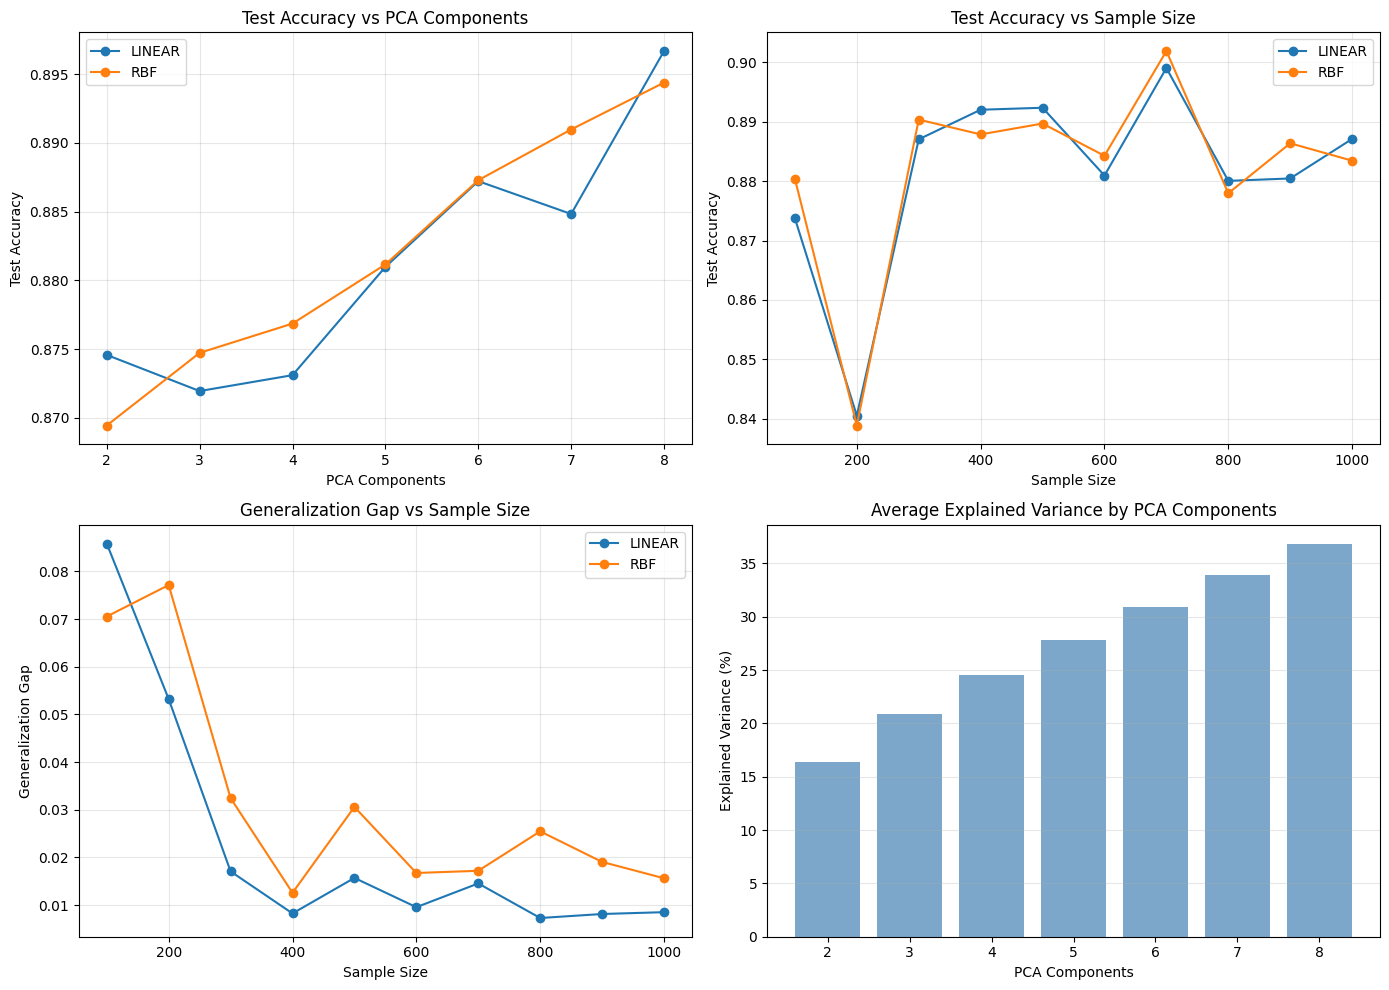

Visualization saved to classical_svm_pca_analysis.png


In [7]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Test Accuracy by PCA Components and Kernel
ax1 = axes[0, 0]
for kernel in ['linear', 'rbf']:
    kernel_data = results_df[results_df['kernel'] == kernel]
    comp_means = kernel_data.groupby('n_components')['test_accuracy'].mean()
    ax1.plot(comp_means.index, comp_means.values, marker='o', label=kernel.upper())
ax1.set_xlabel('PCA Components')
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Test Accuracy vs PCA Components')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Test Accuracy by Sample Size and Kernel
ax2 = axes[0, 1]
for kernel in ['linear', 'rbf']:
    kernel_data = results_df[results_df['kernel'] == kernel]
    sample_means = kernel_data.groupby('samples')['test_accuracy'].mean()
    ax2.plot(sample_means.index, sample_means.values, marker='o', label=kernel.upper())
ax2.set_xlabel('Sample Size')
ax2.set_ylabel('Test Accuracy')
ax2.set_title('Test Accuracy vs Sample Size')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Generalization Gap by Sample Size
ax3 = axes[1, 0]
for kernel in ['linear', 'rbf']:
    kernel_data = results_df[results_df['kernel'] == kernel]
    sample_gap = kernel_data.groupby('samples')['generalization_gap'].mean()
    ax3.plot(sample_gap.index, sample_gap.values, marker='o', label=kernel.upper())
ax3.set_xlabel('Sample Size')
ax3.set_ylabel('Generalization Gap')
ax3.set_title('Generalization Gap vs Sample Size')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Explained Variance by PCA Components
ax4 = axes[1, 1]
comp_var = results_df.groupby('n_components')['explained_variance_ratio'].mean()
ax4.bar(comp_var.index, comp_var.values, color='steelblue', alpha=0.7)
ax4.set_xlabel('PCA Components')
ax4.set_ylabel('Explained Variance (%)')
ax4.set_title('Average Explained Variance by PCA Components')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('classical_svm_pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved to classical_svm_pca_analysis.png")

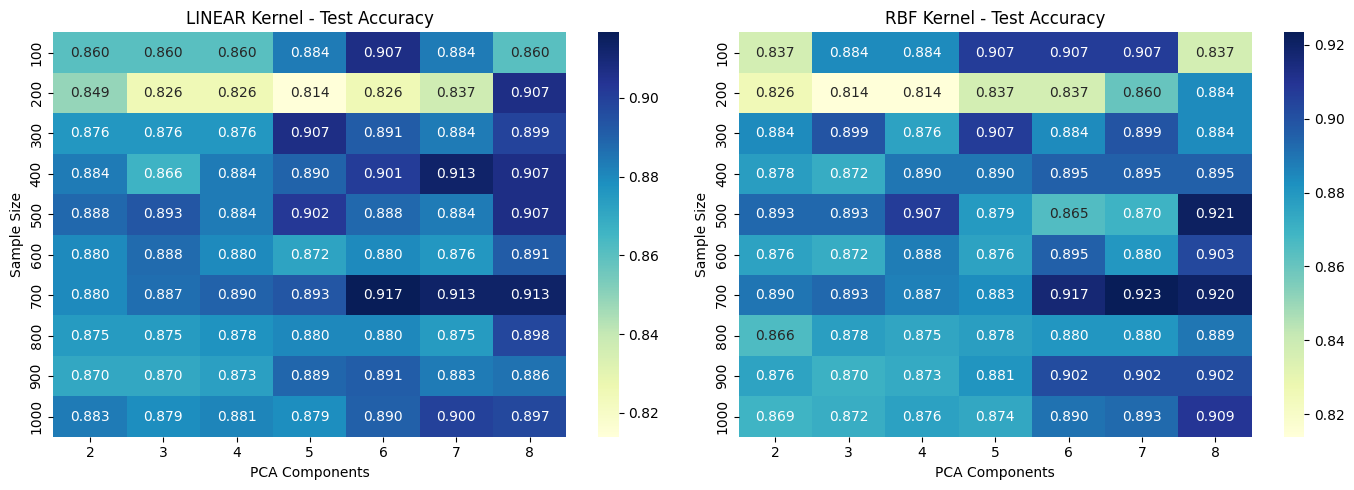

Heatmaps saved to classical_svm_pca_heatmaps.png


In [8]:
# Create heatmaps for different kernels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, kernel in enumerate(['linear', 'rbf']):
    kernel_data = results_df[results_df['kernel'] == kernel]
    pivot = kernel_data.pivot_table(
        values='test_accuracy', 
        index='samples', 
        columns='n_components',
        aggfunc='mean'
    )
    
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[idx])
    axes[idx].set_title(f'{kernel.upper()} Kernel - Test Accuracy')
    axes[idx].set_xlabel('PCA Components')
    axes[idx].set_ylabel('Sample Size')

plt.tight_layout()
plt.savefig('classical_svm_pca_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

print("Heatmaps saved to classical_svm_pca_heatmaps.png")